### Feature Selection with the help of Wrapper method

1. Exhoustice method(Best subset selection)
2. forword selection
3. backword selection
4. recursive feature elimnator

##### 1. Exhoustice method 
###### LogisticRegression

In [9]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import cross_val_score

In [12]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [13]:
import sys
!{sys.executable} -m pip install mlxtend


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import seaborn as sns
df=sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
from mlxtend.feature_selection import  ExhaustiveFeatureSelector as EFS 
lr=LogisticRegression()
sel=EFS(lr,max_features=4,scoring="accuracy",cv=5)

In [16]:
model=sel.fit(df.iloc[:,:4],df["species"])

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Features: 15/15

In [17]:
model.best_score_

np.float64(0.9733333333333334)

In [18]:
model.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [19]:
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.66666667, 0.73333333, 0.76666667, 0.76666667, 0.83333333]),
  'avg_score': np.float64(0.7533333333333333),
  'feature_names': ('sepal_length',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.53333333, 0.56666667, 0.53333333, 0.56666667, 0.63333333]),
  'avg_score': np.float64(0.5666666666666667),
  'feature_names': ('sepal_width',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.93333333, 1.        , 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.9533333333333334),
  'feature_names': ('petal_length',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([1.        , 0.96666667, 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.96),
  'feature_names': ('petal_width',)},
 4: {'feature_idx': (0, 1),
  'cv_scores': array([0.73333333, 0.83333333, 0.76666667, 0.86666667, 0.86666667]),
  'avg_score': np.float64(0.8133333333333332),
  'feature_names': ('sepal_length', 'sepal_width')},
 5: {'feature_idx': 

In [20]:
matrix_df=pd.DataFrame.from_dict(model.get_metric_dict()).T
matrix_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.6666666666666666, 0.7333333333333333, 0.766...",0.753333,"(sepal_length,)",0.069612,0.05416,0.02708
1,"(1,)","[0.5333333333333333, 0.5666666666666667, 0.533...",0.566667,"(sepal_width,)",0.046932,0.036515,0.018257
2,"(2,)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(petal_length,)",0.051412,0.04,0.02
3,"(3,)","[1.0, 0.9666666666666667, 0.9, 0.9333333333333...",0.96,"(petal_width,)",0.049963,0.038873,0.019437
4,"(0, 1)","[0.7333333333333333, 0.8333333333333334, 0.766...",0.813333,"(sepal_length, sepal_width)",0.069612,0.05416,0.02708
5,"(0, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_length, petal_length)",0.051412,0.04,0.02
6,"(0, 3)","[0.9333333333333333, 0.9666666666666667, 0.933...",0.953333,"(sepal_length, petal_width)",0.034274,0.026667,0.013333
7,"(1, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_width, petal_length)",0.051412,0.04,0.02
8,"(1, 3)","[0.9333333333333333, 0.9666666666666667, 0.9, ...",0.94,"(sepal_width, petal_width)",0.032061,0.024944,0.012472
9,"(2, 3)","[0.9666666666666667, 0.9666666666666667, 0.933...",0.96,"(petal_length, petal_width)",0.032061,0.024944,0.012472


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, "('sepal_length',)"),
  Text(1, 0, "('sepal_width',)"),
  Text(2, 0, "('petal_length',)"),
  Text(3, 0, "('petal_width',)"),
  Text(4, 0, "('sepal_length', 'sepal_width')"),
  Text(5, 0, "('sepal_length', 'petal_length')"),
  Text(6, 0, "('sepal_length', 'petal_width')"),
  Text(7, 0, "('sepal_width', 'petal_length')"),
  Text(8, 0, "('sepal_width', 'petal_width')"),
  Text(9, 0, "('petal_length', 'petal_width')"),
  Text(10, 0, "('sepal_length', 'sepal_width', 'petal_length')"),
  Text(11, 0, "('sepal_length', 'sepal_width', 'petal_width')"),
  Text(12, 0, "('sepal_length', 'petal_length', 'petal_width')"),
  Text(13, 0, "('sepal_width', 'petal_length', 'petal_width')"),
  Text(14, 0, "('sepal_length', 'sepal_width', 'petal_length', 'petal_width')")])

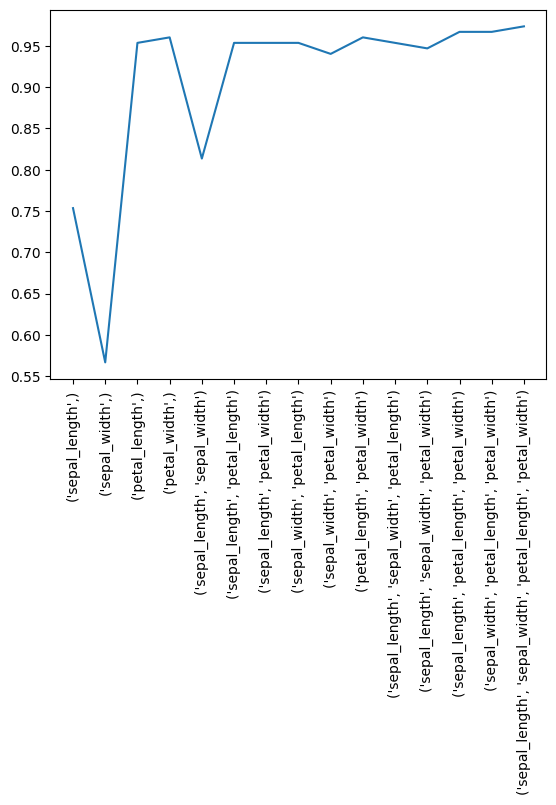

In [21]:
import matplotlib.pyplot as plt
plt.plot([str(k) for k in matrix_df["feature_names"]],matrix_df["avg_score"])
plt.xticks(rotation=90)

#### Regression Example

In [22]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df["medv"],test_size=0.2,random_state=42)

In [24]:
print(x_train.shape)
print(x_test.shape)

(404, 13)
(102, 13)


In [25]:
x_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28


In [26]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [27]:
# Base line model
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
model=LinearRegression()
print("training : ",np.mean(cross_val_score(model,x_train,y_train,cv=5,scoring="r2")))
print("training : ",np.mean(cross_val_score(model,x_test,y_test,cv=5,scoring="r2")))

training :  0.724435734224026
training :  0.5451790940964925


In [28]:
lr=LinearRegression()
exh=EFS(lr,max_features=13,scoring="r2",cv=10,print_progress=True,n_jobs=-1)
sel=exh.fit(x_train,y_train)

Features: 8191/8191

In [29]:
sel.best_feature_names_

('0', '3', '4', '5', '7', '8', '9', '10', '11', '12')

In [30]:
sel.best_score_

np.float64(0.7021432332186084)

In [ ]:
mat_df=pd.DataFrame.from_dict(sel.get_metric_dict()).T
mat_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.06187201349312821, 0.21695752952290703, 0.1...",0.1113,"(0,)",0.068626,0.092399,0.0308
1,"(1,)","[-0.06909411223332595, 0.06378364489046917, 0....",0.080141,"(1,)",0.043549,0.058635,0.019545
2,"(2,)","[0.2581400495130045, 0.24192652096087108, 0.15...",0.197438,"(2,)",0.056161,0.075616,0.025205
3,"(3,)","[-0.06519180407233627, -0.11570770910402528, 0...",0.002908,"(3,)",0.057893,0.077949,0.025983
4,"(4,)","[0.18831320204786572, 0.15611671149828166, 0.1...",0.15303,"(4,)",0.053874,0.072536,0.024179
...,...,...,...,...,...,...,...
8186,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7903768760758775, 0.7978748201943937, 0.742...",0.698955,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.110196,0.14837,0.049457
8187,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7793809319729096, 0.7920049721169651, 0.753...",0.699647,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.115985,0.156164,0.052055
8188,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7802485152933576, 0.8031632921683025, 0.754...",0.698545,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.117601,0.15834,0.05278
8189,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7851529306013899, 0.7726604948432467, 0.749...",0.69279,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.116607,0.157001,0.052334


In [ ]:
def adjust_r2(r2,num_examples,num_features):
    coef=(num_examples-1)/(num_examples-num_features-1)
    return 1-(1-r2)*coef

In [ ]:

mat_df["observations"]=404
mat_df["num_features"]=mat_df["feature_idx"].apply(lambda x:len(x))
mat_df["adjusted_r2"]=adjust_r2(mat_df["avg_score"],mat_df["observations"],mat_df["num_features"])


In [34]:
mat_df.sort_values('adjusted_r2',ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
7590,"(0, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7948781300135748, 0.8126032997049035, 0.740...",0.701604,"(0, 4, 5, 7, 8, 9, 10, 11, 12)",0.109782,0.147812,0.049271,404,9,0.694787
8029,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7853673828678086, 0.8068527620446221, 0.753...",0.702143,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.115758,0.155859,0.051953,404,10,0.694564
7975,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7916866437250346, 0.8002117305356403, 0.740...",0.701376,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.108014,0.145431,0.048477,404,10,0.693777
8150,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7824493530648429, 0.7949109285480953, 0.753...",0.702035,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.114302,0.153898,0.051299,404,11,0.693673
7566,"(0, 3, 4, 5, 7, 8, 10, 11, 12)","[0.7682279280336335, 0.8030267188370753, 0.762...",0.700389,"(0, 3, 4, 5, 7, 8, 10, 11, 12)",0.119573,0.160996,0.053665,404,9,0.693545
...,...,...,...,...,...,...,...,...,...,...
1,"(1,)","[-0.06909411223332595, 0.06378364489046917, 0....",0.080141,"(1,)",0.043549,0.058635,0.019545,404,1,0.077853
30,"(1, 7)","[-0.06763615312808446, 0.06933915753701958, 0....",0.077769,"(1, 7)",0.043101,0.058032,0.019344,404,2,0.07317
49,"(3, 7)","[-0.050810320515409346, -0.042849300889358455,...",0.065037,"(3, 7)",0.066554,0.089609,0.02987,404,2,0.060374
7,"(7,)","[-0.020714728360076817, 0.06907241897075367, 0...",0.036859,"(7,)",0.036497,0.04914,0.01638,404,1,0.034463


#### Sequential Backward Selection / Eliminator

In [35]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [37]:
x=df.drop("medv",axis=1)
y=df["medv"]

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [36]:
model=LinearRegression()
print("training : ",np.mean(cross_val_score(model,x_train,y_train,cv=5,scoring="r2")))
print("training : ",np.mean(cross_val_score(model,x_test,y_test,cv=5,scoring="r2")))

training :  0.724435734224026
training :  0.5451790940964925


In [55]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Create the model
lr = LinearRegression()

# Perform Backward Elimination
sfs = SFS(
    lr,
    k_features="best",
    forward=False,
    floating=False,
    scoring="r2",
    cv=5
)

# Fit on training data
sfs.fit(x_train, y_train)

,estimator,LinearRegression()
,k_features,"(1, ...)"
,forward,False
,scoring,'r2'
,floating,False
,verbose,0
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [56]:
sfs.k_feature_idx_

(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)

In [57]:
mat_df=pd.DataFrame.from_dict(sfs.get_metric_dict()).T
mat_df
def adjust_r2(r2,num_examples,num_features):
    coef=(num_examples-1)/(num_examples-num_features-1)
    return 1-(1-r2)*coef
mat_df["observations"]=404
mat_df["num_features"]=mat_df["feature_idx"].apply(lambda x:len(x))
mat_df["adjusted_r2"]=adjust_r2(mat_df["avg_score"],mat_df["observations"],mat_df["num_features"])
mat_df


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.775019824549236, 0.6242494504269511, 0.7594...",0.724436,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.081659,0.063534,0.031767,404,13,0.71525
12,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7803845935030926, 0.6251539177074756, 0.759...",0.725636,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.082429,0.064133,0.032066,404,12,0.717216
11,"(0, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7884547664556616, 0.6205822778720615, 0.753...",0.726015,"(0, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.087825,0.068331,0.034165,404,11,0.718327
10,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.788177428705694, 0.6205265408146725, 0.7552...",0.726122,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.087944,0.068424,0.034212,404,10,0.719153
9,"(0, 3, 4, 5, 7, 8, 10, 11, 12)","[0.7795789280495411, 0.617544752281958, 0.7496...",0.723533,"(0, 3, 4, 5, 7, 8, 10, 11, 12)",0.087503,0.06808,0.03404,404,9,0.717218
8,"(0, 3, 4, 5, 7, 10, 11, 12)","[0.7758510999506723, 0.6153634894090882, 0.740...",0.719883,"(0, 3, 4, 5, 7, 10, 11, 12)",0.093221,0.072529,0.036265,404,8,0.71421
7,"(3, 4, 5, 7, 10, 11, 12)","[0.7693061589941235, 0.6161051136591214, 0.733...",0.717804,"(3, 4, 5, 7, 10, 11, 12)",0.091209,0.070964,0.035482,404,7,0.712816
6,"(4, 5, 7, 10, 11, 12)","[0.7788452493110056, 0.6218554113167254, 0.720...",0.712919,"(4, 5, 7, 10, 11, 12)",0.093501,0.072747,0.036374,404,6,0.70858
5,"(4, 5, 7, 10, 12)","[0.7524334458987962, 0.6197369305300298, 0.716...",0.700108,"(4, 5, 7, 10, 12)",0.090735,0.070595,0.035298,404,5,0.696341
4,"(5, 7, 10, 12)","[0.716280239608241, 0.6023240279107933, 0.7052...",0.680996,"(5, 7, 10, 12)",0.087197,0.067843,0.033921,404,4,0.677798


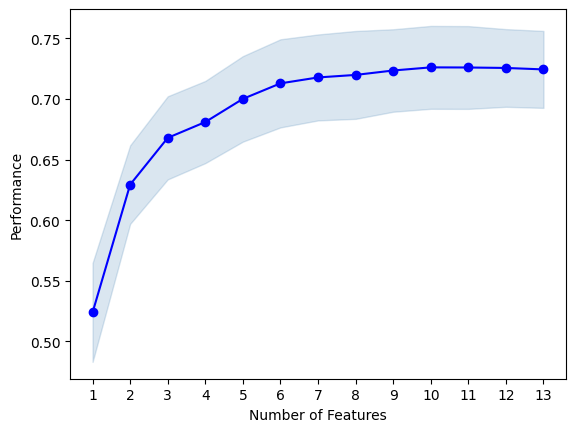

In [58]:
from mlxtend.plotting import plot_sequential_feature_selection as plot  
fig=plot(sfs.get_metric_dict(),kind="std_err")

### Forward Selection

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [15]:
df.shape

(506, 14)

In [13]:
x=df.drop(["medv"],axis=1)
y=df["medv"]

In [14]:
x.shape

(506, 13)

In [18]:
#libraries import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)

(404, 13)
(102, 13)


In [28]:
print("Befor scaler data")
x_train.head(2)

Befor scaler data


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
477,15.02340,0.0,18.10,0,0.614,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.538,5.834,56.5,4.4986,4,307,21.0,395.62,8.47


In [29]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print("After Scaler")
x_train


After Scaler


array([[ 1.28770177, -0.50032012,  1.03323679, ...,  0.84534281,
        -0.07433689,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, ...,  1.20474139,
         0.4301838 , -0.5614742 ],
       [-0.40325332,  1.01327135, -0.71521823, ..., -0.63717631,
         0.06529747, -0.65159505],
       ...,
       [-0.40547014,  2.95931752, -1.30336132, ..., -0.59225149,
         0.37901005, -0.91069248],
       [ 0.85189733, -0.50032012,  1.03323679, ...,  0.84534281,
        -2.69458597,  1.52257036],
       [-0.38135592, -0.50032012, -0.35216694, ...,  1.15981657,
        -3.12158061, -0.25731635]], shape=(404, 13))

In [34]:
import numpy as np
from sklearn.model_selection import cross_val_score
model=LinearRegression()
print("training :",np.mean(cross_val_score(model,x_train,y_train,cv=5,scoring="r2")))
print("training :",np.mean(cross_val_score(model,x_test,y_test,cv=5,scoring="r2")))

training : 0.724435734224026
training : 0.5451790940964925


In [49]:
# (0, 3, 4, 5, 7, 8, 9, 10, 11, 12) //backward
# ('0', '3', '4', '5', '7', '8', '9', '10', '11', '12')//first
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
lr=LinearRegression()
sfs1=SFS(lr,k_features="best",cv=5,forward=True,scoring="r2")
sfs1.fit(x_train,y_train)

,estimator,LinearRegression()
,k_features,"(1, ...)"
,scoring,'r2'
,forward,True
,floating,False
,verbose,0
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [50]:
sfs1.k_feature_idx_

(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)

In [60]:
mat_df=pd.DataFrame.from_dict(sfs1.get_metric_dict()).T
mat_df
def adjust_r2(r2,num_examples,num_features):
    coef=(num_examples-1)/(num_examples-num_features-1)
    return 1-(1-r2)*coef
mat_df["observations"]=404
mat_df["num_features"]=mat_df["feature_idx"].apply(lambda x:len(x))
mat_df["adjusted_r2"]=adjust_r2(mat_df["avg_score"],mat_df["observations"],mat_df["num_features"])
mat_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
1,"(12,)","[0.4271362866520366, 0.5927086587043352, 0.567...",0.523798,"(12,)",0.104953,0.081657,0.040829,404,1,0.522613
2,"(5, 12)","[0.6392367014361816, 0.5532060915883089, 0.682...",0.629351,"(5, 12)",0.083338,0.06484,0.03242,404,2,0.627502
3,"(5, 10, 12)","[0.7054837843327969, 0.5807832925979115, 0.677...",0.667932,"(5, 10, 12)",0.088186,0.068612,0.034306,404,3,0.665442
4,"(5, 10, 11, 12)","[0.7378036058092382, 0.5844120492108217, 0.675...",0.681383,"(5, 10, 11, 12)",0.09243,0.071914,0.035957,404,4,0.678189
5,"(5, 7, 10, 11, 12)","[0.7555271928014686, 0.6108537430892611, 0.708...",0.699202,"(5, 7, 10, 11, 12)",0.088983,0.069232,0.034616,404,5,0.695423
6,"(4, 5, 7, 10, 11, 12)","[0.7788452493110056, 0.6218554113167254, 0.720...",0.712919,"(4, 5, 7, 10, 11, 12)",0.093501,0.072747,0.036374,404,6,0.70858
7,"(3, 4, 5, 7, 10, 11, 12)","[0.7693061589941235, 0.6161051136591214, 0.733...",0.717804,"(3, 4, 5, 7, 10, 11, 12)",0.091209,0.070964,0.035482,404,7,0.712816
8,"(0, 3, 4, 5, 7, 10, 11, 12)","[0.7758510999506723, 0.6153634894090882, 0.740...",0.719883,"(0, 3, 4, 5, 7, 10, 11, 12)",0.093221,0.072529,0.036265,404,8,0.71421
9,"(0, 3, 4, 5, 7, 8, 10, 11, 12)","[0.7795789280495411, 0.617544752281958, 0.7496...",0.723533,"(0, 3, 4, 5, 7, 8, 10, 11, 12)",0.087503,0.06808,0.03404,404,9,0.717218
10,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.788177428705694, 0.6205265408146725, 0.7552...",0.726122,"(0, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.087944,0.068424,0.034212,404,10,0.719153


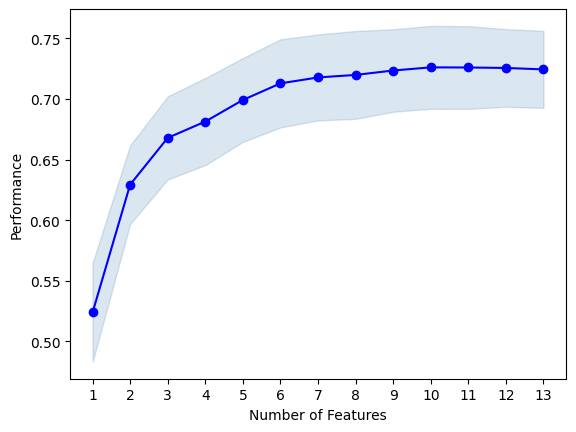

In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as plot  
fig=plot(sfs1.get_metric_dict(),kind="std_err")
